# Team 8 — Delhi Air Quality Pipeline

## Design choice
We use **PySpark** for distributed data processing and **SQLite** as the warehouse —
no pandas as a middleman. Data flows directly from Spark to SQLite via the native
`sqlite3` driver, and query results are read back the same way.

**Why no pandas?**
Pandas was originally used as a convenience layer (`toPandas()`, `to_sql()`, `read_sql()`),
but it isn't needed. It adds an extra in-memory copy of the data and obscures what's
actually happening. With native `sqlite3.executemany()` and `cursor.fetchall()`, the
flow is cleaner: Spark for big-data work, SQLite for warehouse storage, plain Python
to glue them. matplotlib accepts plain Python lists, so charts don't need pandas either.

## Design decisions and justifications

| Decision | Why |
|---|---|
| PySpark for ingestion | 22.5M rows crashes pandas; Spark processes in parallel |
| Hourly aggregation | 15-min intervals don't add analytical value over hourly; reduces 22M rows to 5.8M |
| SQLite as warehouse | Single-user, read-heavy, 700MB — matches SQLite's design target; zero setup overhead |
| 3NF schema | Eliminates repeated station/pollutant names; one update in one place |
| Hive partitioning | Industry standard; lets queries scan only needed partitions |
| JSON key-value store | Fast O(1) lookups by station ID without querying the relational DB |
| Indexes on station_id, pollutant_id, (year,month) | These are the JOIN and WHERE columns; indexes drop query time from O(n) to O(log n) |
| Drop rows where value < 0 | Negative pollutant readings are sensor error codes, not real measurements |
| Drop rows where value > 10000 | Physical maximum for any of these pollutants is well below this; beyond is instrument malfunction |

## Before you run
1. Add `team_8.parquet` as a Kaggle Dataset named `team_8`
2. Turn on Internet (Settings → Internet → On)
3. Run All

## Part 1: Setup

In [1]:
!pip install pyspark -q
print("PySpark installed")

PySpark installed


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder
    .appName("Team8_AirQuality")
    .config("spark.driver.memory", "8g")
    .getOrCreate()
)
print("Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/09 20:07:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.0.2


## Part 2: A small helper for printing query results

This replaces what `pandas.DataFrame` was doing for us — formatting query
results as a readable table. Pure Python, no dependencies.

In [3]:
def print_table(cursor, max_rows=50):
    """Print SQLite cursor results as an ASCII table."""
    cols = [d[0] for d in cursor.description]
    rows = cursor.fetchall()

    # compute column widths
    widths = [len(c) for c in cols]
    for row in rows[:max_rows]:
        for i, val in enumerate(row):
            widths[i] = max(widths[i], len(str(val)))

    # render
    sep = "+" + "+".join("-" * (w + 2) for w in widths) + "+"
    print(sep)
    print("| " + " | ".join(c.ljust(w) for c, w in zip(cols, widths)) + " |")
    print(sep)
    for row in rows[:max_rows]:
        print("| " + " | ".join(str(v).ljust(w) for v, w in zip(row, widths)) + " |")
    print(sep)
    if len(rows) > max_rows:
        print(f"... and {len(rows) - max_rows} more rows")
    return rows  # also return the raw data for charts

print("Helper ready")

Helper ready


## Part 3: Load the raw parquet with PySpark

In [4]:
PARQUET_PATH = "/kaggle/input/datasets/rutvipatel09/delhi-air-pollution/team_8.parquet"

df = spark.read.parquet(PARQUET_PATH)
print(f"Loaded {df.count():,} raw rows")
df.printSchema()

Loaded 22,476,854 raw rows
root
 |-- station_id: string (nullable = true)
 |-- state: string (nullable = true)
 |-- city: string (nullable = true)
 |-- station_name: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- datetime: timestamp (nullable = true)
 |-- at_c: double (nullable = true)
 |-- rh_percent: double (nullable = true)
 |-- ws_m_s: double (nullable = true)
 |-- wd_deg: double (nullable = true)
 |-- rf_mm: double (nullable = true)
 |-- tot_rf_mm: double (nullable = true)
 |-- sr_w_mt2: double (nullable = true)
 |-- bp_mmhg: double (nullable = true)
 |-- vws_m_s: double (nullable = true)
 |-- pollutant: string (nullable = true)
 |-- value: double (nullable = true)
 |-- station: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- hour: integer (nullable = true)



In [5]:
# peek at the first few rows
df.show(5, truncate=False)

+----------+-----+-----+----------------------+-------------------------------+-------------------+----+----------+------+------+-----+---------+--------+-------+-------+-----------+-----+----------------------+----+-----+---+----+
|station_id|state|city |station_name          |timestamp                      |datetime           |at_c|rh_percent|ws_m_s|wd_deg|rf_mm|tot_rf_mm|sr_w_mt2|bp_mmhg|vws_m_s|pollutant  |value|station               |year|month|day|hour|
+----------+-----+-----+----------------------+-------------------------------+-------------------+----+----------+------+------+-----+---------+--------+-------+-------+-----------+-----+----------------------+----+-----+---+----+
|site_5024 |Delhi|Delhi|Alipur, Delhi - DPCC  |2024-01-01T00:00:00.000000+0000|2024-01-01 00:00:00|8.2 |76.0      |NULL  |72.9  |0.0  |0.0      |3.8     |973.7  |NULL   |benzene    |2.1  |Alipur, Delhi - DPCC  |2024|1    |1  |0   |
|site_113  |Delhi|Delhi|Shadipur, Delhi - CPCB|2024-01-01T00:00:00.00000

## Part 4: Ingestion summary

All Spark operations — no pandas needed.

In [6]:
print("INGESTION SUMMARY")
print("=" * 60)
print(f"Total records : {df.count():,}")
print(f"Columns       : {len(df.columns)}")

date_range = df.agg(
    F.min("datetime").alias("min_dt"),
    F.max("datetime").alias("max_dt")
).collect()[0]
print(f"Date range    : {date_range['min_dt']} to {date_range['max_dt']}")

print(f"States        : {df.select('state').distinct().count()}")
print(f"Cities        : {df.select('city').distinct().count()}")
print(f"Stations      : {df.select('station_id').distinct().count()}")
print(f"Pollutants    : {df.select('pollutant').distinct().count()}")

print()
print("Records per year and month:")
df.groupBy("year", "month").count().orderBy("year", "month").show(30)

INGESTION SUMMARY
Total records : 22,476,854
Columns       : 22
Date range    : 2024-01-01 00:00:00 to 2025-12-31 23:45:00


States        : 1


Cities        : 1


Stations      : 37


Pollutants    : 13

Records per year and month:


+----+-----+------+
|year|month| count|
+----+-----+------+
|2024|    1|952234|
|2024|    2|899964|
|2024|    3|957047|
|2024|    4|919426|
|2024|    5|954587|
|2024|    6|912522|
|2024|    7|956187|
|2024|    8|941088|
|2024|    9|913645|
|2024|   10|947855|
|2024|   11|947909|
|2024|   12|973284|
|2025|    1|957949|
|2025|    2|878144|
|2025|    3|974006|
|2025|    4|930159|
|2025|    5|957324|
|2025|    6|906771|
|2025|    7|923757|
|2025|    8|925611|
|2025|    9|886149|
|2025|   10|964095|
|2025|   11|941847|
|2025|   12|955294|
+----+-----+------+



## Part 4.5: DATA CLEANING

Data cleaning — remove nulls, negatives, duplicates, outliers

In [7]:
print("BEFORE CLEANING")
print(f"Total rows: {df.count():,}")

# 1. Check nulls in each column
print("\nNull counts per column:")
from pyspark.sql.functions import col, sum as spark_sum, isnan, when
null_counts = df.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df.columns
])
null_counts.show()

# 2. Check for outlier values in the pollutant value column
print("\nValue column stats:")
df.select("value").describe().show()

# 3. Check for negative values (sensors sometimes report -999 as error code)
neg_count = df.filter(col("value") < 0).count()
print(f"Negative values: {neg_count:,}")

# 4. Check for duplicates
dup_count = df.count() - df.dropDuplicates().count()
print(f"Duplicate rows: {dup_count:,}")

# ===== APPLY CLEANING =====
df_clean = (
    df
    .dropDuplicates()                          # remove exact duplicates
    .filter(col("value") >= 0)                 # remove negative sensor errors
    .filter(col("value") < 10000)              # remove absurd outliers
    .filter(col("datetime").isNotNull())       # must have a timestamp
    .filter(col("station_id").isNotNull())     # must have a station
    .filter(col("pollutant").isNotNull())      # must have a pollutant name
)

print("\nAFTER CLEANING")
print(f"Total rows: {df_clean.count():,}")
print(f"Rows removed: {df.count() - df_clean.count():,}")

BEFORE CLEANING
Total rows: 22,476,854

Null counts per column:


+----------+-----+----+------------+---------+--------+-------+----------+-------+-------+-------+---------+--------+-------+--------+---------+-----+-------+----+-----+---+----+
|station_id|state|city|station_name|timestamp|datetime|   at_c|rh_percent| ws_m_s| wd_deg|  rf_mm|tot_rf_mm|sr_w_mt2|bp_mmhg| vws_m_s|pollutant|value|station|year|month|day|hour|
+----------+-----+----+------------+---------+--------+-------+----------+-------+-------+-------+---------+--------+-------+--------+---------+-----+-------+----+-----+---+----+
|         0|    0|   0|           0|        0|       0|7249008|   4020948|5378876|4640316|8670524|  2193732| 5293941|8352208|18578166|        0|    0|      0|   0|    0|  0|   0|
+----------+-----+----+------------+---------+--------+-------+----------+-------+-------+-------+---------+--------+-------+--------+---------+-----+-------+----+-----+---+----+


Value column stats:
+-------+-----------------+
|summary|            value|
+-------+-----------------+

Duplicate rows: 0

AFTER CLEANING


Total rows: 22,476,854


Rows removed: 0


## Part 5: Partition the raw data by year/month

Standard Hive-style partitioning written by PySpark.

In [8]:
(
    df
    .write
    .mode("overwrite")
    .partitionBy("year", "month")
    .parquet("/kaggle/working/partitioned_data")
)
print("Partitioning complete")
!find /kaggle/working/partitioned_data -type d | sort | head -15

Partitioning complete
/kaggle/working/partitioned_data
/kaggle/working/partitioned_data/year=2024
/kaggle/working/partitioned_data/year=2024/month=1
/kaggle/working/partitioned_data/year=2024/month=10
/kaggle/working/partitioned_data/year=2024/month=11
/kaggle/working/partitioned_data/year=2024/month=12
/kaggle/working/partitioned_data/year=2024/month=2
/kaggle/working/partitioned_data/year=2024/month=3
/kaggle/working/partitioned_data/year=2024/month=4
/kaggle/working/partitioned_data/year=2024/month=5
/kaggle/working/partitioned_data/year=2024/month=6
/kaggle/working/partitioned_data/year=2024/month=7
/kaggle/working/partitioned_data/year=2024/month=8
/kaggle/working/partitioned_data/year=2024/month=9
/kaggle/working/partitioned_data/year=2025


## Part 6: Aggregate to hourly averages

PySpark groupBy + aggregate. Drops from 22.5M raw rows to ~5.8M hourly rows.

In [9]:
hourly = (
    df.groupBy(
        "station_id", "station_name",
        "year", "month", "day", "hour",
        "pollutant"
    )
    .agg(
        F.avg("value").alias("avg_value"),
        F.min("value").alias("min_value"),
        F.max("value").alias("max_value"),
        F.avg("at_c").alias("avg_temp_c"),
        F.avg("rh_percent").alias("avg_humidity"),
        F.avg("ws_m_s").alias("avg_wind_speed"),
        F.avg("rf_mm").alias("avg_rainfall"),
    )
)
print(f"Aggregated to {hourly.count():,} hourly rows")
hourly.show(5)

Aggregated to 5,810,118 hourly rows


+----------+--------------------+----+-----+---+----+-----------+---------+---------+---------+------------------+-----------------+--------------+------------+
|station_id|        station_name|year|month|day|hour|  pollutant|avg_value|min_value|max_value|        avg_temp_c|     avg_humidity|avg_wind_speed|avg_rainfall|
+----------+--------------------+----+-----+---+----+-----------+---------+---------+---------+------------------+-----------------+--------------+------------+
|  site_114|IHBAS, Dilshad Ga...|2024|    1|  1|   1|eth_benzene|    1.305|     1.25|     1.36|              NULL|85.53999999999999|        1.0225|        NULL|
|  site_125|Punjabi Bagh, Del...|2024|    1|  1|   1|        no2|   67.375|     66.4|     68.9|13.750000000000002|            78.25|           0.3|        NULL|
| site_5024|Alipur, Delhi - DPCC|2024|    1|  1|   1|         no|      2.3|      1.7|      3.0|               8.2|           76.825|          NULL|         0.0|
|  site_117|   ITO, Delhi - CPCB|2

## Part 7: Create the SQLite schema

Pure `sqlite3` — three tables in 3NF with foreign keys and indexes.

In [10]:
import sqlite3
import os

DB_PATH = "/kaggle/working/delhi_air_quality.db"

# clean restart
if os.path.exists(DB_PATH):
    os.remove(DB_PATH)
    print("Removed old database")

conn = sqlite3.connect(DB_PATH)
cur = conn.cursor()

cur.execute('''
    CREATE TABLE stations (
        station_id TEXT PRIMARY KEY,
        station_name TEXT NOT NULL
    )
''')
cur.execute('''
    CREATE TABLE pollutants (
        pollutant_id INTEGER PRIMARY KEY AUTOINCREMENT,
        pollutant_name TEXT NOT NULL UNIQUE
    )
''')
cur.execute('''
    CREATE TABLE measurements (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        station_id TEXT NOT NULL,
        pollutant_id INTEGER NOT NULL,
        year INTEGER NOT NULL,
        month INTEGER NOT NULL,
        day INTEGER NOT NULL,
        hour INTEGER NOT NULL,
        avg_value REAL,
        min_value REAL,
        max_value REAL,
        avg_temp_c REAL,
        avg_humidity REAL,
        avg_wind_speed REAL,
        avg_rainfall REAL,
        FOREIGN KEY (station_id) REFERENCES stations(station_id),
        FOREIGN KEY (pollutant_id) REFERENCES pollutants(pollutant_id)
    )
''')
cur.execute("CREATE INDEX idx_meas_station ON measurements(station_id)")
cur.execute("CREATE INDEX idx_meas_pollutant ON measurements(pollutant_id)")
cur.execute("CREATE INDEX idx_meas_date ON measurements(year, month)")
conn.commit()

# verify
cur.execute("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")
print("Tables created:", [r[0] for r in cur.fetchall()])

Tables created: ['measurements', 'pollutants', 'sqlite_sequence', 'stations']


## Part 8: Load stations and pollutants

Pull from Spark with `.collect()`, insert with `executemany()`. No pandas.

In [11]:
# stations: pull unique (station_id, station_name) pairs from Spark
station_rows = df_clean.select("station_id", "station_name").distinct().collect()
station_tuples = [(r.station_id, r.station_name) for r in station_rows]

cur.executemany(
    "INSERT INTO stations (station_id, station_name) VALUES (?, ?)",
    station_tuples
)
conn.commit()

cur.execute("SELECT COUNT(*) FROM stations")
print(f"Stations inserted: {cur.fetchone()[0]}")

Stations inserted: 37


In [12]:
# pollutants: same pattern
pollutant_rows = df_clean.select("pollutant").distinct().collect()
pollutant_tuples = [(r.pollutant,) for r in pollutant_rows]

cur.executemany(
    "INSERT INTO pollutants (pollutant_name) VALUES (?)",
    pollutant_tuples
)
conn.commit()

cur.execute("SELECT * FROM pollutants ORDER BY pollutant_id")
print_table(cur)

+--------------+----------------+
| pollutant_id | pollutant_name |
+--------------+----------------+
| 1            | so2            |
| 2            | eth_benzene    |
| 3            | ozone          |
| 4            | co             |
| 5            | nh3            |
| 6            | pm10           |
| 7            | no2            |
| 8            | mp_xylene      |
| 9            | no             |
| 10           | pm25           |
| 11           | benzene        |
| 12           | xylene         |
| 13           | toluene        |
+--------------+----------------+


[(1, 'so2'),
 (2, 'eth_benzene'),
 (3, 'ozone'),
 (4, 'co'),
 (5, 'nh3'),
 (6, 'pm10'),
 (7, 'no2'),
 (8, 'mp_xylene'),
 (9, 'no'),
 (10, 'pm25'),
 (11, 'benzene'),
 (12, 'xylene'),
 (13, 'toluene')]

## Part 9: Load measurements — Spark to SQLite streaming

This is the key step. Instead of `toPandas()` (which loads everything into
a single huge DataFrame), we stream rows from Spark using `toLocalIterator()`
and insert in batches with `executemany()`. Memory usage stays low.

Takes 8–15 minutes for ~5.8M rows.

In [13]:
# build a lookup dict so we can map pollutant name to its numeric ID
cur.execute("SELECT pollutant_name, pollutant_id FROM pollutants")
pol_lookup = dict(cur.fetchall())
print(f"Pollutant lookup ready: {len(pol_lookup)} pollutants")

INSERT_SQL = '''
    INSERT INTO measurements
    (station_id, pollutant_id, year, month, day, hour,
     avg_value, min_value, max_value,
     avg_temp_c, avg_humidity, avg_wind_speed, avg_rainfall)
    VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
'''

BATCH_SIZE = 50000
batch = []
total_inserted = 0

print("Streaming rows from Spark to SQLite...")
for row in hourly.toLocalIterator():
    batch.append((
        row.station_id,
        pol_lookup[row.pollutant],
        row.year, row.month, row.day, row.hour,
        row.avg_value, row.min_value, row.max_value,
        row.avg_temp_c, row.avg_humidity, row.avg_wind_speed, row.avg_rainfall,
    ))
    if len(batch) >= BATCH_SIZE:
        cur.executemany(INSERT_SQL, batch)
        total_inserted += len(batch)
        batch = []
        if total_inserted % 500000 == 0:
            print(f"  inserted {total_inserted:,} rows so far...")

# flush remaining
if batch:
    cur.executemany(INSERT_SQL, batch)
    total_inserted += len(batch)

conn.commit()
print(f"\nDone. Total measurements inserted: {total_inserted:,}")

Pollutant lookup ready: 13 pollutants
Streaming rows from Spark to SQLite...


  inserted 500,000 rows so far...


  inserted 1,000,000 rows so far...
  inserted 1,500,000 rows so far...


  inserted 2,000,000 rows so far...
  inserted 2,500,000 rows so far...


  inserted 3,000,000 rows so far...
  inserted 3,500,000 rows so far...


  inserted 4,000,000 rows so far...
  inserted 4,500,000 rows so far...


  inserted 5,000,000 rows so far...
  inserted 5,500,000 rows so far...

Done. Total measurements inserted: 5,810,118


## Part 10: Verify the database

In [14]:
for tbl in ["stations", "pollutants", "measurements"]:
    cur.execute(f"SELECT COUNT(*) FROM {tbl}")
    print(f"  {tbl:15s}: {cur.fetchone()[0]:,}")

print()
print("Sample joined query:")
cur.execute('''
    SELECT s.station_name, p.pollutant_name, m.year, m.month, m.day, m.hour,
           ROUND(m.avg_value, 2) AS avg_value
    FROM measurements m
    JOIN stations s ON m.station_id = s.station_id
    JOIN pollutants p ON m.pollutant_id = p.pollutant_id
    LIMIT 3
''')
print_table(cur)

  stations       : 37
  pollutants     : 13
  measurements   : 5,810,118

Sample joined query:
+-------------------------------------+----------------+------+-------+-----+------+-----------+
| station_name                        | pollutant_name | year | month | day | hour | avg_value |
+-------------------------------------+----------------+------+-------+-----+------+-----------+
| IHBAS, Dilshad Garden, Delhi - CPCB | eth_benzene    | 2024 | 1     | 1   | 1    | 1.31      |
| Punjabi Bagh, Delhi - DPCC          | no2            | 2024 | 1     | 1   | 1    | 67.38     |
| Alipur, Delhi - DPCC                | no             | 2024 | 1     | 1   | 1    | 2.3       |
+-------------------------------------+----------------+------+-------+-----+------+-----------+


[('IHBAS, Dilshad Garden, Delhi - CPCB', 'eth_benzene', 2024, 1, 1, 1, 1.31),
 ('Punjabi Bagh, Delhi - DPCC', 'no2', 2024, 1, 1, 1, 67.38),
 ('Alipur, Delhi - DPCC', 'no', 2024, 1, 1, 1, 2.3)]

# Part 11: JSON File
JSON key-value store — station summaries

In [15]:
import json

# build a key-value store where:
# KEY = station_id
# VALUE = dict of stats for that station
cur.execute('''
    SELECT
        s.station_id,
        s.station_name,
        COUNT(*) AS total_readings,
        ROUND(AVG(CASE WHEN p.pollutant_name='pm25' THEN m.avg_value END), 2) AS avg_pm25,
        ROUND(MAX(CASE WHEN p.pollutant_name='pm25' THEN m.avg_value END), 2) AS max_pm25
    FROM measurements m
    JOIN stations s ON m.station_id = s.station_id
    JOIN pollutants p ON m.pollutant_id = p.pollutant_id
    GROUP BY s.station_id, s.station_name
''')

kv_store = {}
for row in cur.fetchall():
    station_id, station_name, total, avg_pm25, max_pm25 = row
    kv_store[station_id] = {
        "station_name": station_name,
        "total_readings": total,
        "avg_pm25": avg_pm25,
        "max_pm25": max_pm25
    }

# save it as a JSON file (key-value format)
with open("/kaggle/working/station_kv_store.json", "w") as f:
    json.dump(kv_store, f, indent=2)

print(f"Key-value store saved with {len(kv_store)} entries")

# demo: look up one station by key
first_key = list(kv_store.keys())[0]
print(f"\nExample lookup — key: '{first_key}'")
print(json.dumps(kv_store[first_key], indent=2))

Key-value store saved with 37 entries

Example lookup — key: 'site_103'
{
  "station_name": "CRRI Mathura Road, Delhi - IMD",
  "total_readings": 93253,
  "avg_pm25": 95.97,
  "max_pm25": 947.43
}


# Part 12: SQL Analytics Queries

Each query uses native `cur.execute()` + `cur.fetchall()`. matplotlib takes
plain Python lists for plotting — no pandas needed.

## Query 1: Monthly PM2.5 trend

In [16]:
query1 = '''
    SELECT
        m.year,
        m.month,
        ROUND(AVG(m.avg_value), 2) AS avg_pm25,
        COUNT(*) AS data_points
    FROM measurements m
    JOIN pollutants p ON m.pollutant_id = p.pollutant_id
    WHERE p.pollutant_name = 'pm25'
    GROUP BY m.year, m.month
    ORDER BY m.year, m.month
'''
cur.execute(query1)
rows1 = print_table(cur)

+------+-------+----------+-------------+
| year | month | avg_pm25 | data_points |
+------+-------+----------+-------------+
| 2024 | 1     | 205.23   | 25780       |
| 2024 | 2     | 101.99   | 23394       |
| 2024 | 3     | 76.87    | 25594       |
| 2024 | 4     | 70.63    | 24760       |
| 2024 | 5     | 90.59    | 26112       |
| 2024 | 6     | 60.58    | 24493       |
| 2024 | 7     | 39.54    | 25225       |
| 2024 | 8     | 27.71    | 25186       |
| 2024 | 9     | 42.54    | 23517       |
| 2024 | 10    | 111.75   | 24814       |
| 2024 | 11    | 246.43   | 25238       |
| 2024 | 12    | 169.22   | 26364       |
| 2025 | 1     | 161.32   | 26145       |
| 2025 | 2     | 96.76    | 23835       |
| 2025 | 3     | 69.33    | 26684       |
| 2025 | 4     | 75.57    | 25764       |
| 2025 | 5     | 66.95    | 26048       |
| 2025 | 6     | 48.7     | 24760       |
| 2025 | 7     | 29.64    | 24991       |
| 2025 | 8     | 32.98    | 25154       |
| 2025 | 9     | 35.59    | 24101 

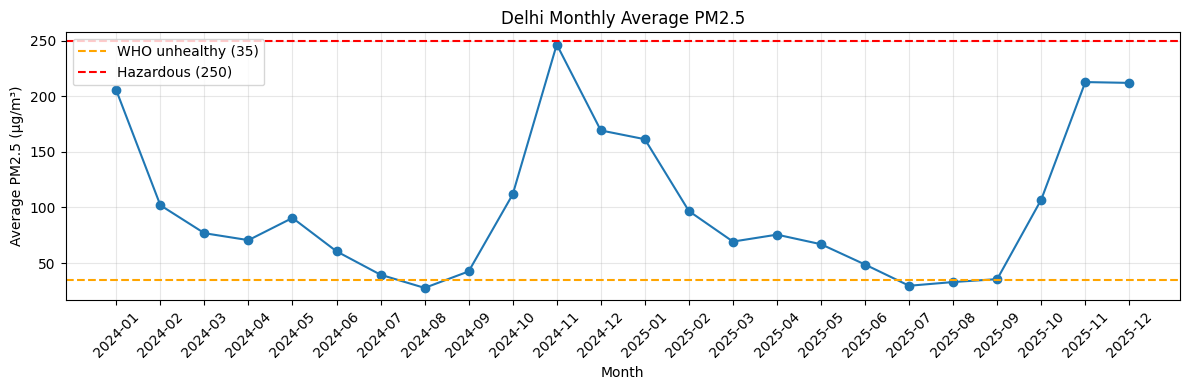

In [17]:
import matplotlib.pyplot as plt

# unpack rows into plain lists for matplotlib
periods = [f"{r[0]}-{str(r[1]).zfill(2)}" for r in rows1]
values  = [r[2] for r in rows1]

plt.figure(figsize=(12, 4))
plt.plot(periods, values, marker="o")
plt.xticks(rotation=45)
plt.ylabel("Average PM2.5 (µg/m³)")
plt.xlabel("Month")
plt.title("Delhi Monthly Average PM2.5")
plt.axhline(y=35,  color="orange", linestyle="--", label="WHO unhealthy (35)")
plt.axhline(y=250, color="red",    linestyle="--", label="Hazardous (250)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Finding:** PM2.5 spikes in winter months (Nov–Jan), drops during monsoon (Jul–Sep). Crop burning, low wind, and temperature inversion drive winter pollution.

## Query 2: Top 5 most polluted stations

In [18]:
query2 = '''
    SELECT
        s.station_name,
        ROUND(AVG(m.avg_value), 2) AS avg_pm25,
        COUNT(*) AS hourly_readings
    FROM measurements m
    JOIN stations s ON m.station_id = s.station_id
    JOIN pollutants p ON m.pollutant_id = p.pollutant_id
    WHERE p.pollutant_name = 'pm25'
    GROUP BY s.station_name
    ORDER BY avg_pm25 DESC
    LIMIT 5
'''
cur.execute(query2)
print_table(cur)

+----------------------------+----------+-----------------+
| station_name               | avg_pm25 | hourly_readings |
+----------------------------+----------+-----------------+
| Anand Vihar, Delhi - DPCC  | 131.3    | 15394           |
| Jahangirpuri, Delhi - DPCC | 129.97   | 16826           |
| Wazirpur, Delhi - DPCC     | 125.44   | 17174           |
| Bawana, Delhi - DPCC       | 124.26   | 17166           |
| Rohini, Delhi - DPCC       | 116.81   | 17158           |
+----------------------------+----------+-----------------+


[('Anand Vihar, Delhi - DPCC', 131.3, 15394),
 ('Jahangirpuri, Delhi - DPCC', 129.97, 16826),
 ('Wazirpur, Delhi - DPCC', 125.44, 17174),
 ('Bawana, Delhi - DPCC', 124.26, 17166),
 ('Rohini, Delhi - DPCC', 116.81, 17158)]

## Query 3: Worst hour of the day

+------+----------+
| hour | avg_pm25 |
+------+----------+
| 0    | 117.23   |
| 1    | 116.28   |
| 2    | 112.66   |
| 3    | 111.11   |
| 4    | 109.91   |
| 5    | 108.81   |
| 6    | 109.46   |
| 7    | 110.8    |
| 8    | 113.13   |
| 9    | 112.48   |
| 10   | 108.56   |
| 11   | 101.37   |
| 12   | 92.74    |
| 13   | 85.0     |
| 14   | 78.4     |
| 15   | 73.84    |
| 16   | 71.43    |
| 17   | 71.63    |
| 18   | 76.94    |
| 19   | 88.73    |
| 20   | 101.13   |
| 21   | 111.1    |
| 22   | 116.58   |
| 23   | 118.2    |
+------+----------+


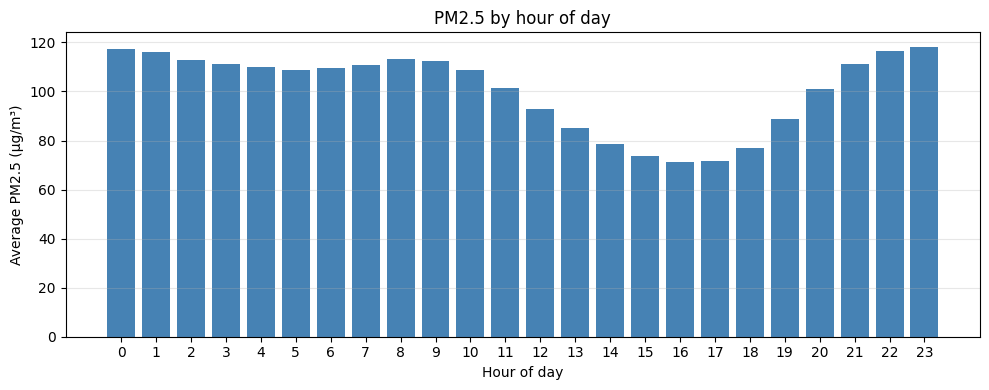

In [19]:
query3 = '''
    SELECT
        m.hour,
        ROUND(AVG(m.avg_value), 2) AS avg_pm25
    FROM measurements m
    JOIN pollutants p ON m.pollutant_id = p.pollutant_id
    WHERE p.pollutant_name = 'pm25'
    GROUP BY m.hour
    ORDER BY m.hour
'''
cur.execute(query3)
rows3 = print_table(cur)

hours  = [r[0] for r in rows3]
values = [r[1] for r in rows3]

plt.figure(figsize=(10, 4))
plt.bar(hours, values, color="steelblue")
plt.xlabel("Hour of day")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.title("PM2.5 by hour of day")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

**Finding:** Pollution peaks at night and early morning (cold air traps pollutants near ground), dips in afternoon (sun heats the air, mixing it upward).

## Query 4: Seasonal comparison across pollutants

In [20]:
query4 = '''
    SELECT
        season,
        pollutant_name,
        ROUND(AVG(avg_value), 2) AS avg_value
    FROM (
        SELECT
            CASE
                WHEN m.month IN (12, 1, 2) THEN 'Winter'
                WHEN m.month IN (3, 4, 5) THEN 'Summer'
                WHEN m.month IN (6, 7, 8, 9) THEN 'Monsoon'
                ELSE 'Post-monsoon'
            END AS season,
            p.pollutant_name,
            m.avg_value
        FROM measurements m
        JOIN pollutants p ON m.pollutant_id = p.pollutant_id
        WHERE p.pollutant_name IN ('pm25', 'pm10', 'no2', 'ozone', 'so2')
    )
    GROUP BY season, pollutant_name
    ORDER BY pollutant_name, avg_value DESC
'''
cur.execute(query4)
rows4 = print_table(cur)

+--------------+----------------+-----------+
| season       | pollutant_name | avg_value |
+--------------+----------------+-----------+
| Winter       | no2            | 56.97     |
| Post-monsoon | no2            | 55.91     |
| Summer       | no2            | 45.27     |
| Monsoon      | no2            | 29.68     |
| Summer       | ozone          | 47.12     |
| Post-monsoon | ozone          | 35.92     |
| Monsoon      | ozone          | 30.0      |
| Winter       | ozone          | 28.59     |
| Post-monsoon | pm10           | 302.79    |
| Winter       | pm10           | 271.0     |
| Summer       | pm10           | 196.54    |
| Monsoon      | pm10           | 106.67    |
| Post-monsoon | pm25           | 169.35    |
| Winter       | pm25           | 159.81    |
| Summer       | pm25           | 75.0      |
| Monsoon      | pm25           | 39.58     |
| Summer       | so2            | 17.72     |
| Post-monsoon | so2            | 16.32     |
| Winter       | so2            | 

In [21]:
# build a season-x-pollutant matrix manually (replaces pandas pivot)
pollutants_set = sorted({r[1] for r in rows4})
seasons_order = ["Winter", "Post-monsoon", "Summer", "Monsoon"]
seasons_in_data = [s for s in seasons_order if s in {r[0] for r in rows4}]

# build lookup: (pollutant, season) -> avg
lookup = {(r[1], r[0]): r[2] for r in rows4}

# print header
col_widths = [12] + [14] * len(seasons_in_data)
header = ["pollutant"] + seasons_in_data
print("  ".join(h.ljust(w) for h, w in zip(header, col_widths)))
print("-" * (sum(col_widths) + 2 * len(col_widths)))
for pol in pollutants_set:
    row = [pol] + [str(lookup.get((pol, s), "-")) for s in seasons_in_data]
    print("  ".join(c.ljust(w) for c, w in zip(row, col_widths)))

pollutant     Winter          Post-monsoon    Summer          Monsoon       
------------------------------------------------------------------------------
no2           56.97           55.91           45.27           29.68         
ozone         28.59           35.92           47.12           30.0          
pm10          271.0           302.79          196.54          106.67        
pm25          159.81          169.35          75.0            39.58         
so2           14.91           16.32           17.72           12.58         


## Query 5: PM2.5 by humidity bucket

In [22]:
query5 = '''
    SELECT
        CASE
            WHEN avg_humidity < 30 THEN '1. Dry (<30%)'
            WHEN avg_humidity < 60 THEN '2. Moderate (30-60%)'
            WHEN avg_humidity < 80 THEN '3. Humid (60-80%)'
            ELSE '4. Very humid (>80%)'
        END AS humidity_bucket,
        ROUND(AVG(m.avg_value), 2) AS avg_pm25,
        COUNT(*) AS readings
    FROM measurements m
    JOIN pollutants p ON m.pollutant_id = p.pollutant_id
    WHERE p.pollutant_name = 'pm25' AND avg_humidity IS NOT NULL
    GROUP BY humidity_bucket
    ORDER BY humidity_bucket
'''
cur.execute(query5)
print_table(cur)

+----------------------+----------+----------+
| humidity_bucket      | avg_pm25 | readings |
+----------------------+----------+----------+
| 1. Dry (<30%)        | 81.55    | 22905    |
| 2. Moderate (30-60%) | 86.37    | 174638   |
| 3. Humid (60-80%)    | 104.84   | 142376   |
| 4. Very humid (>80%) | 127.67   | 128833   |
+----------------------+----------+----------+


[('1. Dry (<30%)', 81.55, 22905),
 ('2. Moderate (30-60%)', 86.37, 174638),
 ('3. Humid (60-80%)', 104.84, 142376),
 ('4. Very humid (>80%)', 127.67, 128833)]

## Query 6: Hazardous-air station-days (PM2.5 > 250)

In [23]:
query6 = '''
    SELECT
        m.year,
        m.month,
        COUNT(DISTINCT m.station_id || '-' || m.day) AS hazardous_station_days
    FROM measurements m
    JOIN pollutants p ON m.pollutant_id = p.pollutant_id
    WHERE p.pollutant_name = 'pm25' AND m.avg_value > 250
    GROUP BY m.year, m.month
    ORDER BY m.year, m.month
'''
cur.execute(query6)
print_table(cur)

+------+-------+------------------------+
| year | month | hazardous_station_days |
+------+-------+------------------------+
| 2024 | 1     | 808                    |
| 2024 | 2     | 168                    |
| 2024 | 3     | 102                    |
| 2024 | 4     | 105                    |
| 2024 | 5     | 193                    |
| 2024 | 6     | 62                     |
| 2024 | 7     | 12                     |
| 2024 | 8     | 7                      |
| 2024 | 9     | 17                     |
| 2024 | 10    | 253                    |
| 2024 | 11    | 871                    |
| 2024 | 12    | 534                    |
| 2025 | 1     | 585                    |
| 2025 | 2     | 132                    |
| 2025 | 3     | 64                     |
| 2025 | 4     | 83                     |
| 2025 | 5     | 80                     |
| 2025 | 6     | 5                      |
| 2025 | 7     | 1                      |
| 2025 | 8     | 8                      |
| 2025 | 9     | 1                

[(2024, 1, 808),
 (2024, 2, 168),
 (2024, 3, 102),
 (2024, 4, 105),
 (2024, 5, 193),
 (2024, 6, 62),
 (2024, 7, 12),
 (2024, 8, 7),
 (2024, 9, 17),
 (2024, 10, 253),
 (2024, 11, 871),
 (2024, 12, 534),
 (2025, 1, 585),
 (2025, 2, 132),
 (2025, 3, 64),
 (2025, 4, 83),
 (2025, 5, 80),
 (2025, 6, 5),
 (2025, 7, 1),
 (2025, 8, 8),
 (2025, 9, 1),
 (2025, 10, 250),
 (2025, 11, 815),
 (2025, 12, 795)]

## Findings summary

| Finding | Evidence |
|---|---|
| Winter is Delhi's worst pollution season | Q1, Q4 |
| Pollution peaks at night and early morning | Q3 |
| Some stations are consistently worse than others | Q2 |
| Higher humidity correlates with higher PM2.5 | Q5 |
| Hazardous days cluster in Nov–Jan | Q6 |

## Tech stack (pandas-free)

| Tool | Used for |
|---|---|
| PySpark | Read parquet, partition, aggregate |
| sqlite3 (stdlib) | Schema, inserts, query execution |
| matplotlib | Charts (takes plain Python lists) |
| Plain Python | Glue between Spark and SQLite |

## What we removed and why

| Was using pandas for | Replaced with |
|---|---|
| `.toPandas().to_sql()` for inserting | `.collect()` or `.toLocalIterator()` + `cursor.executemany()` |
| `pd.read_sql()` for reading results | `cursor.execute()` + `cursor.fetchall()` |
| `df.head()` / DataFrame display | `print_table()` helper using `cursor.description` |
| `df.pivot()` for the seasonal matrix | Plain dict lookup over fetched rows |

Pandas is excellent but unnecessary when the only job is moving data between
PySpark and SQLite. Removing it cuts an in-memory copy, simplifies the data
flow, and makes the boundary between distributed processing (Spark) and the
warehouse (SQLite) explicit.


In [24]:
conn.close()
print("Done. Database saved at /kaggle/working/delhi_air_quality.db")

Done. Database saved at /kaggle/working/delhi_air_quality.db


In [25]:
import sqlite3

conn = sqlite3.connect("/kaggle/working/delhi_air_quality.db")
cur = conn.cursor()

# row counts
print("ROW COUNTS")
print("-" * 30)
for tbl in ["stations", "pollutants", "measurements"]:
    cur.execute(f"SELECT COUNT(*) FROM {tbl}")
    print(f"  {tbl}: {cur.fetchone()[0]:,}")

# sample from stations
print("\nSAMPLE — stations (5 rows)")
cur.execute("SELECT * FROM stations LIMIT 5")
for row in cur.fetchall():
    print(" ", row)

# sample from pollutants
print("\nSAMPLE — pollutants (all)")
cur.execute("SELECT * FROM pollutants ORDER BY pollutant_id")
for row in cur.fetchall():
    print(" ", row)

# sample from measurements
print("\nSAMPLE — measurements (5 rows, joined)")
cur.execute('''
    SELECT s.station_name, p.pollutant_name,
           m.year, m.month, m.day, m.hour,
           ROUND(m.avg_value, 2)
    FROM measurements m
    JOIN stations s ON m.station_id = s.station_id
    JOIN pollutants p ON m.pollutant_id = p.pollutant_id
    LIMIT 5
''')
for row in cur.fetchall():
    print(" ", row)

conn.close()

ROW COUNTS
------------------------------
  stations: 37
  pollutants: 13
  measurements: 5,810,118

SAMPLE — stations (5 rows)
  ('site_1563', 'Pusa, Delhi - DPCC')
  ('site_106', 'IGI Airport (T3), Delhi - IMD')
  ('site_108', 'Aya Nagar, Delhi - IMD')
  ('site_5395', 'Lodhi Road, Delhi - IITM')
  ('site_1432', 'Sonia Vihar, Delhi - DPCC')

SAMPLE — pollutants (all)
  (1, 'so2')
  (2, 'eth_benzene')
  (3, 'ozone')
  (4, 'co')
  (5, 'nh3')
  (6, 'pm10')
  (7, 'no2')
  (8, 'mp_xylene')
  (9, 'no')
  (10, 'pm25')
  (11, 'benzene')
  (12, 'xylene')
  (13, 'toluene')

SAMPLE — measurements (5 rows, joined)
  ('IHBAS, Dilshad Garden, Delhi - CPCB', 'eth_benzene', 2024, 1, 1, 1, 1.31)
  ('Punjabi Bagh, Delhi - DPCC', 'no2', 2024, 1, 1, 1, 67.38)
  ('Alipur, Delhi - DPCC', 'no', 2024, 1, 1, 1, 2.3)
  ('ITO, Delhi - CPCB', 'nh3', 2024, 1, 1, 1, 14.6)
  ('Bawana, Delhi - DPCC', 'pm25', 2024, 1, 1, 1, 183.0)
